In [1]:
import warnings
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.feature_selection import f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# Add src to path
sys.path.append(str(Path('..').resolve()))
from src.utils.paths import RESULTS_DIR, RAW_DIR, PROCESSED_DIR, PROJECT_ROOT

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Project root:', PROJECT_ROOT)
print('Processed dir exists:', PROCESSED_DIR.exists())

Project root: /home/bendavison/PycharmProjects/msc_dissertation
Processed dir exists: True


In [2]:
# Load processed datasets used in modelling
dataset_A = pd.read_csv(PROCESSED_DIR / 'dataset_A_full.csv')
dataset_B = pd.read_csv(PROCESSED_DIR / 'dataset_B_metabolomics.csv')
dataset_C = pd.read_csv(PROCESSED_DIR / 'dataset_C_transcriptomics.csv')

# Load cleaned modality-level tables for sample coverage exploration
met_clean = pd.read_csv(PROCESSED_DIR / 'metabolomics_clean.csv')
micro_clean = pd.read_csv(PROCESSED_DIR / 'microbiota_clean.csv')
trans_clean = pd.read_csv(PROCESSED_DIR / 'transcriptomics_clean.csv')
weights_clean = pd.read_csv(PROCESSED_DIR / 'weights_clean.csv')
questionnaires_clean = pd.read_csv(PROCESSED_DIR / 'questionnaires_clean.csv')

target_col = 'absolute weight change '
exclude_cols = {'participant_id', target_col}


def feature_cols(df):
    return [c for c in df.columns if c not in exclude_cols]


print('Loaded datasets A/B/C and cleaned modality tables.')

Loaded datasets A/B/C and cleaned modality tables.


## Dataset-level

- `participants`/`rows`: effective sample size available for analysis.
- `features`: predictor dimensionality (excluding ID + target).
- `WL_features` vs `WM_features`: balance between weight-loss and maintenance velocity information.
- `target_missing`: whether any samples cannot be used for supervised analyses.

In [3]:
# High-level overview: participants, features, target availability
overview = []
for name, df in [('Dataset A (full)', dataset_A), ('Dataset B (metabolomics)', dataset_B),
                 ('Dataset C (transcriptomics)', dataset_C)]:
    feats = feature_cols(df)
    overview.append({
        'dataset': name,
        'rows': len(df),
        'participants': df['participant_id'].nunique(),
        'features': len(feats),
        'target_missing': int(df[target_col].isna().sum()),
        'WL_features': sum(c.startswith('WL_vel_') for c in feats),
        'WM_features': sum(c.startswith('WM_vel_') for c in feats)
    })

overview_df = pd.DataFrame(overview)
overview_df

,dataset,rows,participants,features,target_missing,WL_features,WM_features
0,Dataset A (full),33,33,1174,0,587,587
1,Dataset B (metabolomics),79,79,204,0,102,102
2,Dataset C (transcriptomics),31,31,210,0,105,105


## Modality-level

**What this means:**
- Shows raw/cleaned table breadth by modality.
- `timepoints` confirms whether longitudinal structure is present.
- `features` helps explain why some modalities are harder to model.

In [4]:
# Modality-level sample coverage and feature counts (cleaned tables)
def modality_summary(name, df):
    non_meta = [c for c in df.columns if
                c not in ['sample_id', 'participant_id', 'timepoint', 'group', 'Pair',
                          'Maintenancediet']]
    return {
        'modality': name,
        'rows': len(df),
        'participants': df[
            'participant_id'].nunique() if 'participant_id' in df.columns else np.nan,
        'sample_ids': df['sample_id'].nunique() if 'sample_id' in df.columns else np.nan,
        'timepoints': sorted(
            df['timepoint'].dropna().unique().tolist()) if 'timepoint' in df.columns else [],
        'features': len(non_meta)
    }


modality_df = pd.DataFrame([
    modality_summary('metabolomics_clean', met_clean),
    modality_summary('microbiota_clean', micro_clean),
    modality_summary('transcriptomics_clean', trans_clean),
    modality_summary('weights_clean', weights_clean),
    modality_summary('questionnaires_clean', questionnaires_clean),
])

modality_df

,modality,rows,participants,sample_ids,timepoints,features
0,metabolomics_clean,237,80,235.0,"[1, 2, 4]",97
1,microbiota_clean,99,34,99.0,"[1, 2, 4]",485
2,transcriptomics_clean,89,31,89.0,"[1, 2, 4]",19622
3,weights_clean,82,82,NaN,[],4
4,questionnaires_clean,82,82,NaN,[],942


## 3) Missingness profile

**What this means:**
- `avg_feature_missing_%`: average fraction of missing values across all feature cells.
- `rows_with_any_missing_%`: how many participants have at least one missing feature.

In [5]:
# Missingness overview for model datasets
missing_rows = []
for name, df in [('A', dataset_A), ('B', dataset_B), ('C', dataset_C)]:
    feats = feature_cols(df)
    feat_missing = df[feats].isna().mean().mean() * 100
    row_missing_any = (df[feats].isna().sum(axis=1) > 0).mean() * 100
    missing_rows.append({
        'dataset': name,
        'avg_feature_missing_%': round(feat_missing, 3),
        'rows_with_any_missing_%': round(row_missing_any, 3)
    })

missing_df = pd.DataFrame(missing_rows)
missing_df

,dataset,avg_feature_missing_%,rows_with_any_missing_%
0,A,4.344,100.0
1,B,2.308,100.0
2,C,6.621,100.0


✓ exploration_02_missingness.png


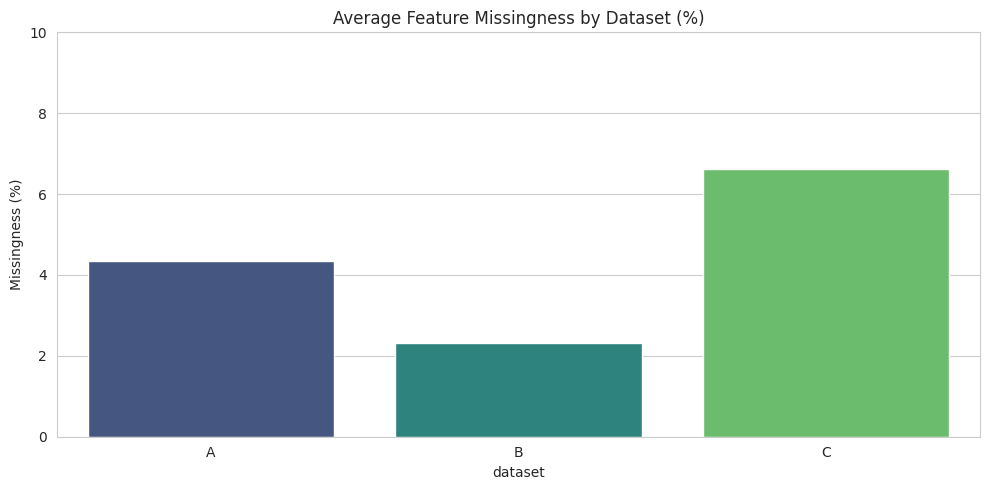

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(data=missing_df, x='dataset', y='avg_feature_missing_%', palette='viridis')
plt.title('Average Feature Missingness by Dataset (%)')
plt.ylabel('Missingness (%)')
plt.ylim(0, 10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'exploration_02_missingness.png', dpi=150, bbox_inches='tight')
print("✓ exploration_02_missingness.png")
plt.show()


## 4) Target distribution (Dataset B)

**What this means:**
- Histogram + KDE: overall shape of target values.
- Boxplot: median, spread, and potential outliers.
- `describe()`: summary stats.

✓ exploration_01_target_dist.png


count    79.000000
mean      1.101895
std       4.026886
min     -11.297710
25%      -0.872269
50%       1.300390
75%       3.695264
max       9.730363
Name: absolute weight change , dtype: float64

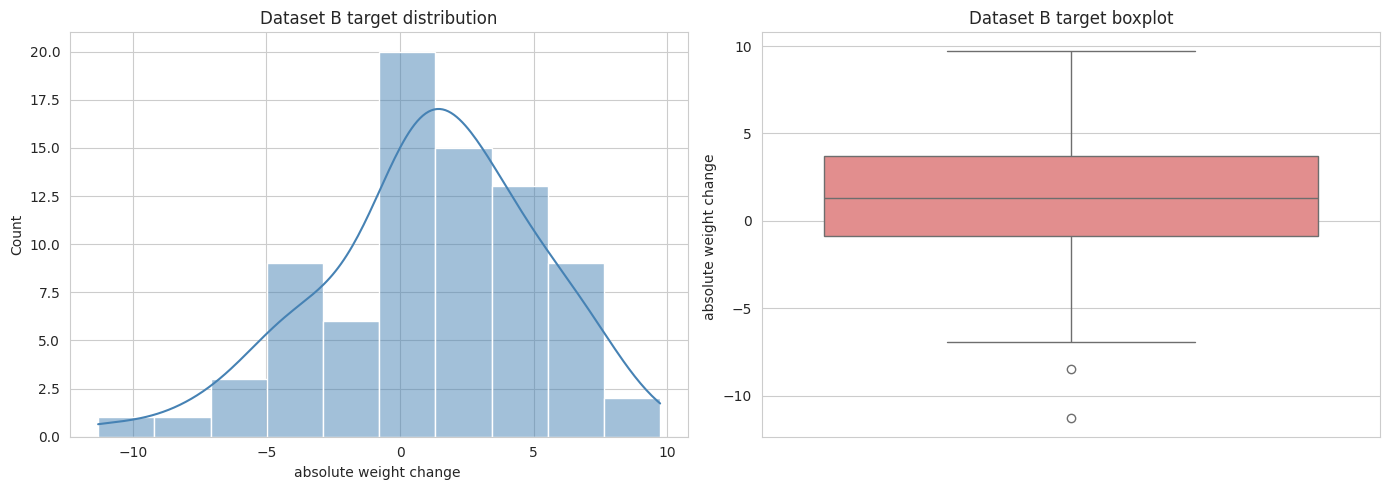

In [7]:
# Target distribution (main dataset B)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(dataset_B[target_col].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Dataset B target distribution')
axes[0].set_xlabel(target_col)

sns.boxplot(y=dataset_B[target_col], ax=axes[1], color='lightcoral')
axes[1].set_title('Dataset B target boxplot')
axes[1].set_ylabel(target_col)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'exploration_01_target_dist.png', dpi=150, bbox_inches='tight')
print("✓ exploration_01_target_dist.png")
dataset_B[target_col].describe()

## WL vs WM paired-feature coupling

**What this means:**
- For each shared feature name, correlates `WL_vel_x` with `WM_vel_x`.
- Distribution of these correlations indicates whether phases move together.

Common WL/WM features: 102


,feature,lowest_corr
22,CAR 4:0;O,-0.909738
36,Hydroxybutanoic acid,-0.899599
86,Unknown carnitine derivative,-0.889102
38,Hydroxyindoleacetic acid,-0.819424
24,CAR 6:0;O,-0.816721
19,CAR 18:2,-0.794955
63,Ornithine,-0.785140
0,Acetylcarnosine,-0.776335
17,CAR 14:1,-0.773625
81,Serine,-0.757076


,feature,highest_corr
98,fatmass,0.060054
97,bmi,0.008815
101,weight,-0.048848
88,Unknown glycosidic compound MW 542.2741,-0.166470
28,Cortisol,-0.184264
99,fatpercent,-0.208693
62,N-Acetyl-L-phenylalanine,-0.276922
25,CAR 8:0,-0.291546
76,Palmitamide,-0.315466
100,waistcircumference,NaN


✓ exploration_03_wl_wm_correlations.png


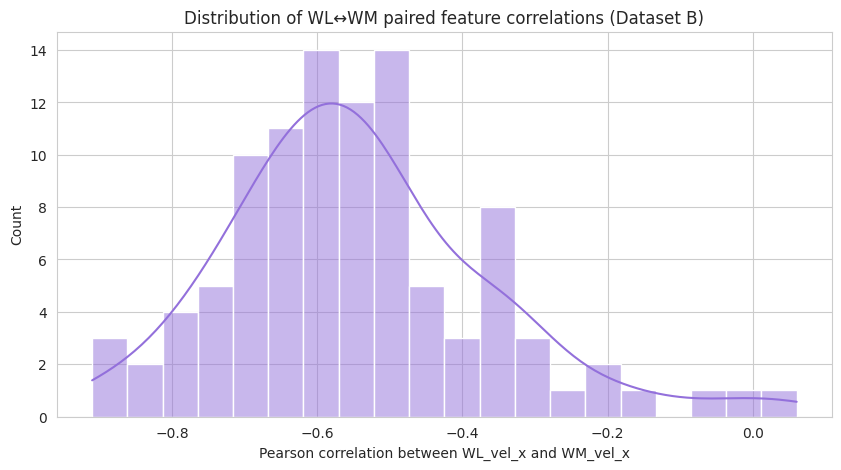

In [8]:
# WL vs WM paired-feature relationship in Dataset B
wl = [c for c in dataset_B.columns if c.startswith('WL_vel_')]
wm = [c for c in dataset_B.columns if c.startswith('WM_vel_')]
wl_base = {c.replace('WL_vel_', ''): c for c in wl}
wm_base = {c.replace('WM_vel_', ''): c for c in wm}
common = sorted(set(wl_base) & set(wm_base))

pair_corrs = []
for feat in common:
    wlc = wl_base[feat]
    wmc = wm_base[feat]
    corr = dataset_B[[wlc, wmc]].corr().iloc[0, 1]
    pair_corrs.append({'feature': feat, 'wl_wm_corr': corr})

pair_corr_df = pd.DataFrame(pair_corrs).sort_values('wl_wm_corr')
print(f'Common WL/WM features: {len(common)}')
display(pair_corr_df.head(10).rename(columns={'wl_wm_corr': 'lowest_corr'}))
display(pair_corr_df.tail(10).sort_values('wl_wm_corr', ascending=False).rename(
    columns={'wl_wm_corr': 'highest_corr'}))

plt.figure(figsize=(10, 5))
sns.histplot(pair_corr_df['wl_wm_corr'], bins=20, kde=True, color='mediumpurple')
plt.title('Distribution of WL↔WM paired feature correlations (Dataset B)')
plt.xlabel('Pearson correlation between WL_vel_x and WM_vel_x')
plt.savefig(RESULTS_DIR / 'exploration_03_wl_wm_correlations.png', dpi=150, bbox_inches='tight')
print("✓ exploration_03_wl_wm_correlations.png")
plt.show()

## Unsupervised clustering of participants (Dataset B)

**What this means:**
- KMeans groups participants by feature profile without using the target.
- Silhouette score chooses the most separable number of clusters (`k`).
- The all-missing-column drop avoids invalid feature alignment.

Dropping 1 all-missing feature(s): ['WM_vel_waistcircumference']


✓ exploration_04_silhouette.png


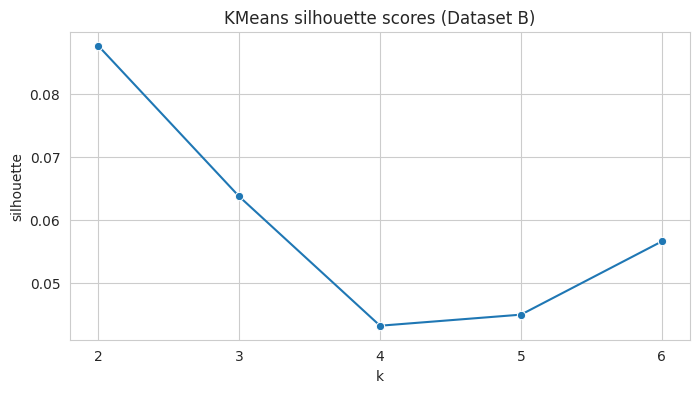

Best k by silhouette: 2


,k,silhouette
0,2,0.087697
1,3,0.063747
2,4,0.043201
3,5,0.044960
4,6,0.056600


In [9]:
# Participant clustering on Dataset B (no PCA)
features_B_all = feature_cols(dataset_B)
X_B = dataset_B[features_B_all].copy()

# Some features can be entirely missing; drop them before imputation
all_missing_cols = X_B.columns[X_B.isna().all()].tolist()
if all_missing_cols:
    print(f'Dropping {len(all_missing_cols)} all-missing feature(s):', all_missing_cols)
X_B = X_B.drop(columns=all_missing_cols)
features_B = X_B.columns.tolist()

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()
X_B_scaled = scaler.fit_transform(imputer.fit_transform(X_B))

silhouette_rows = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_B_scaled)
    sil = silhouette_score(X_B_scaled, labels)
    silhouette_rows.append({'k': k, 'silhouette': sil})

silhouette_df = pd.DataFrame(silhouette_rows)
best_k = int(silhouette_df.sort_values('silhouette', ascending=False).iloc[0]['k'])

plt.figure(figsize=(8, 4))
sns.lineplot(data=silhouette_df, x='k', y='silhouette', marker='o')
plt.title('KMeans silhouette scores (Dataset B)')
plt.xticks(range(2, 7))
plt.savefig(RESULTS_DIR / 'exploration_04_silhouette.png', dpi=150, bbox_inches='tight')
print("✓ exploration_04_silhouette.png")
plt.show()

print('Best k by silhouette:', best_k)
silhouette_df

## Cluster robustness and target profiling

**What this means:**
- `ARI` compares cluster assignments from two different methods.
- High ARI means subgroup structure is not method-specific.
- `cluster_summary` shows whether clusters differ in target level/variance.

In [10]:
# Cluster profiling and method agreement
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_km = kmeans.fit_predict(X_B_scaled)

agg = AgglomerativeClustering(n_clusters=best_k)
labels_agg = agg.fit_predict(X_B_scaled)

ari = adjusted_rand_score(labels_km, labels_agg)
print(f'Adjusted Rand Index (KMeans vs Agglomerative): {ari:.3f}')

cluster_df = dataset_B[['participant_id', target_col]].copy()
cluster_df['cluster'] = labels_km

cluster_summary = cluster_df.groupby('cluster').agg(
    n=('participant_id', 'count'),
    target_mean=(target_col, 'mean'),
    target_std=(target_col, 'std'),
    target_min=(target_col, 'min'),
    target_max=(target_col, 'max')
).reset_index().sort_values('target_mean')

cluster_summary

Adjusted Rand Index (KMeans vs Agglomerative): 0.805


,cluster,n,target_mean,target_std,target_min,target_max
0,0,32,1.073561,4.650893,-8.45987,9.730363
1,1,47,1.121186,3.594184,-11.29771,6.810811


## Which features separate clusters most?

**What this means:**
- ANOVA F-scores rank features by how strongly they differ across clusters.
- Heatmap shows per-cluster average values for top separating features.

,feature,f_score,p_value
186,WM_vel_Unknown phospholipid MW 501.3187,59.941917,3.185126e-11
51,WL_vel_LPC(O-18:1),56.814862,7.863546e-11
156,WM_vel_LPE(P-18:0),54.668526,1.481020e-10
59,WL_vel_LPE(P-18:0),50.375513,5.429524e-10
58,WL_vel_LPE(P-16:0),49.010266,8.286177e-10
50,WL_vel_LPC(O-16:1),48.961426,8.413185e-10
147,WM_vel_LPC(O-16:1),48.585593,9.459912e-10
54,WL_vel_LPE(16:0),47.617081,1.281926e-09
151,WM_vel_LPE(16:0),45.582635,2.446981e-09
48,WL_vel_LPC(20:1),43.790208,4.366076e-09


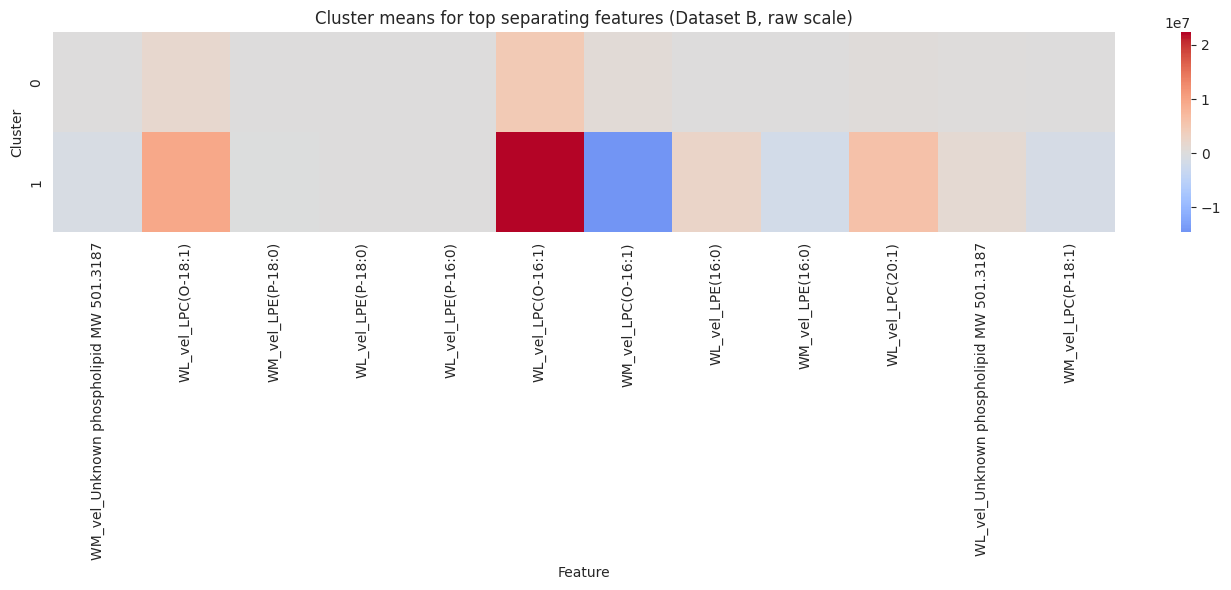

In [11]:
# Which features separate clusters most strongly?
f_vals, p_vals = f_classif(X_B_scaled, labels_km)
cluster_sep = pd.DataFrame({
    'feature': features_B,
    'f_score': f_vals,
    'p_value': p_vals
}).sort_values('f_score', ascending=False)

top_sep = cluster_sep.head(12)['feature'].tolist()
cluster_means = X_B.assign(cluster=labels_km).groupby('cluster')[top_sep].mean()

display(cluster_sep.head(20))

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_means, cmap='coolwarm', center=0)
plt.title('Cluster means for top separating features (Dataset B, raw scale)')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

Feature-Target Correlations
**What this means:**- Correlates each metabolite feature with the outcome (weight change during maintenance)- High correlation = feature is predictive- Low correlation = feature has weak signal

In [12]:
# Feature-target correlations
features_B = feature_cols(dataset_B)
feature_target_corrs = []
for feat in features_B:
    # Only use pairs with valid values
    valid_mask = dataset_B[feat].notna() & dataset_B[target_col].notna()
    if valid_mask.sum() > 2:
        # Need at least 3 points for correlation
        corr = dataset_B.loc[valid_mask, feat].corr(dataset_B.loc[valid_mask, target_col])
        feature_target_corrs.append({'feature': feat, 'correlation': corr, 'abs_corr': abs(corr)})

corr_df = pd.DataFrame(feature_target_corrs).sort_values('abs_corr', ascending=False)

print(f"\nTotal features analyzed: {len(corr_df)}")
print(f"Mean |correlation|: {corr_df['abs_corr'].mean():.4f}")
print(f"Median |correlation|: {corr_df['abs_corr'].median():.4f}")
print(f"Max |correlation|: {corr_df['abs_corr'].max():.4f}")

print(f"\n{'=' * 70}")
print("TOP 15 FEATURES MOST CORRELATED WITH WEIGHT CHANGE")
print("=" * 70)
print(corr_df.head(15)[['feature', 'correlation']].to_string(index=False))

print(f"\n{'=' * 70}")
print("KEY INSIGHT: Anthropometrics vs Metabolites")
print("=" * 70)
anthropo_features = corr_df[
    corr_df['feature'].str.contains('(bmi|weight)')]
metabolite_features = corr_df[
    ~corr_df['feature'].str.contains('(bmi|weight)')]
if len(anthropo_features) > 0:
    print(f"Anthropometric features (top 5):")
    print(anthropo_features.head(5)[['feature', 'correlation']].to_string(index=False))
    print(f"  Mean |r|: {anthropo_features['abs_corr'].mean():.3f}")

    print(f"\nMetabolomic features (top 5):")
    print(metabolite_features.head(5)[['feature', 'correlation']].to_string(index=False))
    print(f"  Mean |r|: {metabolite_features['abs_corr'].mean():.3f}")
    print(f"  Median |r|: {metabolite_features['abs_corr'].median():.3f}")

# Save
corr_df.to_csv(PROCESSED_DIR / 'feature_target_correlations.csv', index=False)
print(f"\n✓ Saved to: data/processed/feature_target_correlations.csv")


Total features analyzed: 203
Mean |correlation|: 0.1196
Median |correlation|: 0.0946
Max |correlation|: 0.9928

TOP 15 FEATURES MOST CORRELATED WITH WEIGHT CHANGE
                                       feature  correlation
                                    WM_vel_bmi     0.992763
                                 WM_vel_weight     0.989424
                                WM_vel_fatmass     0.801857
                             WM_vel_fatpercent     0.504808
                          WM_vel_Indolelactate    -0.406951
                              WM_vel_LPC(17:0)    -0.321227
                             WM_vel_Kynurenine     0.314350
                            WM_vel_LPC(O-16:1)    -0.299263
       WM_vel_Unknown phospholipid MW 501.3187    -0.292823
                            WM_vel_LPC(O-18:1)    -0.283452
                               WL_vel_CAR 18:2    -0.280433
                              WM_vel_LPC(20:1)    -0.269033
WM_vel_Unknown glycosidic compound MW 488.3363     0.262

## Demographic Subgroup Analysis
**What this means:**- Tests whether weight change differs by demographic groups (sex, age, treatment)- If significant, suggests stratified models or demographic confounding- If not significant, suggests individual variation dominates

In [13]:
from scipy import stats

# Load demographic data
questionnaires = pd.read_csv(PROCESSED_DIR / 'questionnaires_clean.csv')
# Merge dataset_B with demographics
merged = dataset_B.merge(questionnaires[['participant_id', 'sex', 'age', 'group']],
                         on='participant_id', how='left')
print(f"\nMerged dataset: {merged.shape}")
print(f"Participants with sex info: {merged['sex'].notna().sum()}")
print(f"Participants with age info: {merged['age'].notna().sum()}")

# ===== SEX SUBGROUP ANALYSIS =====
print(f"\n{'=' * 70}")
print("SEX SUBGROUP ANALYSIS")
print("=" * 70)
sex_groups = []
for sex_val in sorted(merged['sex'].dropna().unique()):
    subset = merged[merged['sex'] == sex_val][target_col].dropna()
    if len(subset) > 0:
        sex_groups.append(
            {'Sex': ['Male', 'Female'][int(sex_val) - 1], 'N': len(subset), 'Mean': subset.mean(),
             'Std': subset.std(), 'Min': subset.min(), 'Max': subset.max()})
sex_df = pd.DataFrame(sex_groups)
display(sex_df.round(2))

# Statistical test
sex_vals = sorted(merged['sex'].dropna().unique())
if len(sex_vals) >= 2:
    group1 = merged[merged['sex'] == sex_vals[0]][target_col].dropna()
    group2 = merged[merged['sex'] == sex_vals[1]][target_col].dropna()
    t_stat, p_val = stats.ttest_ind(group1, group2)
    print(
        f"\nT-test: t={t_stat:.3f}, p={p_val:.4f} {'(significant)' if p_val < 0.05 else '(not significant)'}")

# ===== AGE SUBGROUP ANALYSIS =====
print(f"\n{'=' * 70}")
print("AGE SUBGROUP ANALYSIS (Tertiles)")
print("=" * 70)
merged_age = merged.copy()
merged_age['age_tertile'] = pd.qcut(merged_age['age'].dropna(), q=3,
                                    labels=['Young', 'Mid', 'Old'], duplicates='drop')
age_groups = []
for age_t in ['Young', 'Mid', 'Old']:
    subset = merged_age[merged_age['age_tertile'] == age_t][target_col].dropna()
    if len(subset) > 0:
        age_range = merged_age[merged_age['age_tertile'] == age_t]['age'].describe()
        age_groups.append({'Age Group': age_t,
                           'Age Range': f"{int(age_range['min'])}-{int(age_range['max'])}",
                           'N': len(subset), 'Mean': subset.mean(), 'Std': subset.std(),
                           'Min': subset.min(), 'Max': subset.max()})
age_df = pd.DataFrame(age_groups)
display(age_df.round(2))

# ===== TREATMENT GROUP ANALYSIS =====
print(f"\n{'=' * 70}")
print("TREATMENT GROUP ANALYSIS")
print("=" * 70)
group_list = []
for grp in sorted(merged['group'].dropna().unique()):
    subset = merged[merged['group'] == grp][target_col].dropna()
    if len(subset) > 0:
        group_list.append(
            {'Group': int(grp), 'N': len(subset), 'Mean': subset.mean(),
             'Std': subset.std(), 'Min': subset.min(), 'Max': subset.max()})
group_df = pd.DataFrame(group_list)
display(group_df.round(2))

# Statistical
testgroups = sorted(merged['group'].dropna().unique())
if len(testgroups) >= 2:
    g1 = merged[merged['group'] == testgroups[0]][target_col].dropna()
    g2 = merged[merged['group'] == testgroups[1]][target_col].dropna()
    t_stat, p_val = stats.ttest_ind(g1, g2)
    print(
        f"\nT-test: t={t_stat:.3f}, p={p_val:.4f} {'(significant)' if p_val < 0.05 else '(not significant)'}")

# ===== COMPILE SUMMARY TABLE =====
print(f"\n{'=' * 70}")
print("SUBGROUP SUMMARY TABLE")
print("=" * 70)
summary_data = []

# Sex
for i, sex_val in enumerate([1, 2]):
    subset = merged[merged['sex'] == sex_val][target_col].dropna()
    if len(subset) > 0:
        summary_data.append(
            {'Subgroup': f"Sex={'Male' if sex_val == 1 else 'Female'}",
             'N': len(subset),
             'Mean_Wt_Change_kg': round(subset.mean(), 2),
             'Std': round(subset.std(), 2),
             'Min': round(subset.min(), 2),
             'Max': round(subset.max(), 2)})

# Age
for age_t in ['Young', 'Mid', 'Old']:
    subset = merged_age[merged_age['age_tertile'] == age_t][target_col].dropna()
    if len(subset) > 0:
        summary_data.append(
            {'Subgroup': f"Age={age_t}", 'N': len(subset),
             'Mean_Wt_Change_kg': round(subset.mean(), 2),
             'Std': round(subset.std(), 2),
             'Min': round(subset.min(), 2),
             'Max': round(subset.max(), 2)})

# Treatment
for grp in sorted(merged['group'].dropna().unique()):
    subset = merged[merged['group'] == grp][target_col].dropna()
    if len(subset) > 0:
        summary_data.append(
            {'Subgroup': f"Treatment_Group={int(grp)}",
             'N': len(subset),
             'Mean_Wt_Change_kg': round(subset.mean(),
                                        2),
             'Std': round(subset.std(), 2),
             'Min': round(subset.min(), 2),
             'Max': round(subset.max(), 2)})

summary_table = pd.DataFrame(summary_data)
display(summary_table)
# Save
summary_table.to_csv(
    PROCESSED_DIR / 'subgroup_analysis.csv',
    index=False)
print(
    f"\n✓ Saved to: data/processed/subgroup_analysis.csv")


Merged dataset: (79, 209)
Participants with sex info: 79
Participants with age info: 79

SEX SUBGROUP ANALYSIS


,Sex,N,Mean,Std,Min,Max
0,Male,21,2.05,3.94,-5.25,7.35
1,Female,58,0.76,4.04,-11.30,9.73



T-test: t=1.263, p=0.2104 (not significant)

AGE SUBGROUP ANALYSIS (Tertiles)


,Age Group,Age Range,N,Mean,Std,Min,Max
0,Young,31-45,27,1.93,3.59,-8.46,9.73
1,Mid,46-56,32,0.87,4.47,-11.30,7.35
2,Old,57-63,20,0.36,3.83,-5.25,7.87



TREATMENT GROUP ANALYSIS


,Group,N,Mean,Std,Min,Max
0,1,40,1.27,4.02,-6.93,7.87
1,2,39,0.92,4.08,-11.30,9.73



T-test: t=0.385, p=0.7017 (not significant)

SUBGROUP SUMMARY TABLE


,Subgroup,N,Mean_Wt_Change_kg,Std,Min,Max
0,Sex=Male,21,2.05,3.94,-5.25,7.35
1,Sex=Female,58,0.76,4.04,-11.30,9.73
2,Age=Young,27,1.93,3.59,-8.46,9.73
3,Age=Mid,32,0.87,4.47,-11.30,7.35
4,Age=Old,20,0.36,3.83,-5.25,7.87
5,Treatment_Group=1,40,1.27,4.02,-6.93,7.87
6,Treatment_Group=2,39,0.92,4.08,-11.30,9.73



✓ Saved to: data/processed/subgroup_analysis.csv


Temporal Trajectory Plots
**What this means:**- Visualizes how features evolve from WL phase to WM phase- Shows whether phases move together (correlated) or independently (uncorrelated)- Demonstrates individual vs group patterns

✓ temporal_01_weight_trajectories.png


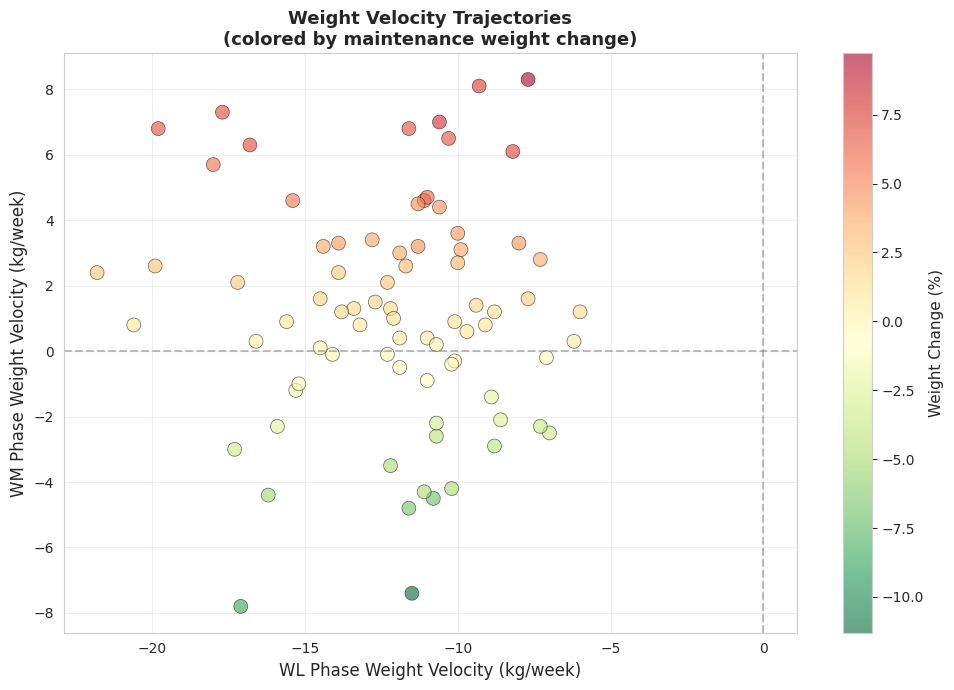

In [14]:
# Plot 1: Weight velocity trajectories
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(dataset_B['WL_vel_weight'], dataset_B['WM_vel_weight'],
                     c=dataset_B[target_col], cmap='RdYlGn_r', s=100, alpha=0.6, edgecolors='black',
                     linewidth=0.5)
ax.set_xlabel('WL Phase Weight Velocity (kg/week)', fontsize=12)
ax.set_ylabel('WM Phase Weight Velocity (kg/week)', fontsize=12)
ax.set_title('Weight Velocity Trajectories\n(colored by maintenance weight change)', fontsize=13,
             fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Weight Change (%)', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'temporal_01_weight_trajectories.png', dpi=150, bbox_inches='tight')
print("✓ temporal_01_weight_trajectories.png")
plt.show()

✓ temporal_02_velocity_changes.png


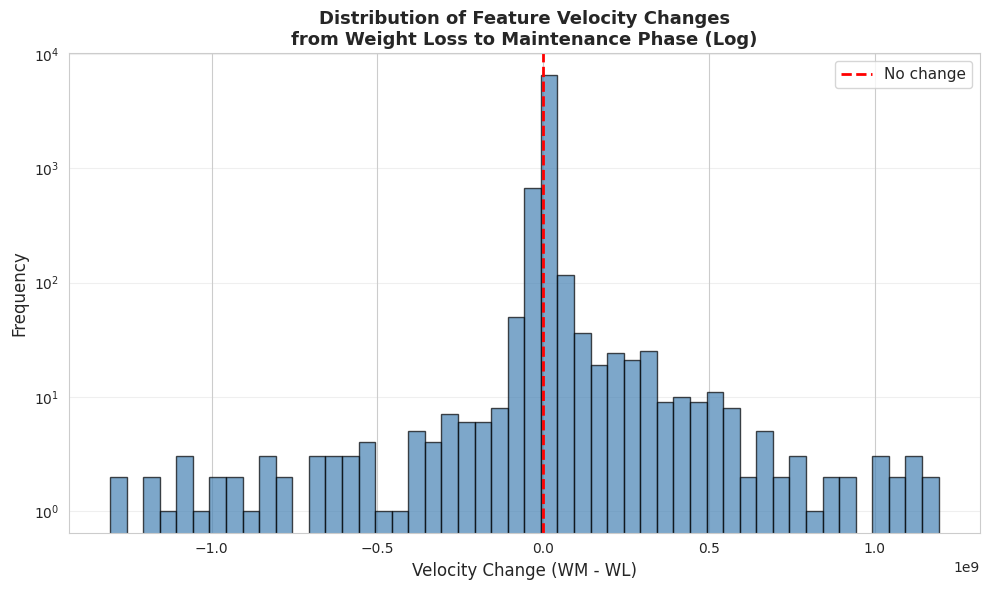

In [15]:
# Plot 2: Feature velocity changes
fig, ax = plt.subplots(figsize=(10, 6))
wl_cols = [c for c in dataset_B.columns if c.startswith('WL_vel_')]
wm_cols = [c for c in dataset_B.columns if c.startswith('WM_vel_')]
velocity_changes = []
for wl, wm in zip(wl_cols, wm_cols):
    data = dataset_B[[wl, wm]].dropna()
    if len(data) > 5:
        velocity_changes.extend(data[wm].values - data[wl].values)

ax.hist(velocity_changes, bins=50, color='steelblue', alpha=0.7, edgecolor='black', log=True)
ax.set_xlabel('Velocity Change (WM - WL)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Feature Velocity Changes\nfrom Weight Loss to Maintenance Phase (Log)',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'temporal_02_velocity_changes.png', dpi=150, bbox_inches='tight')
print("✓ temporal_02_velocity_changes.png")
plt.show()

✓ temporal_03_metabolite_trajectories.png


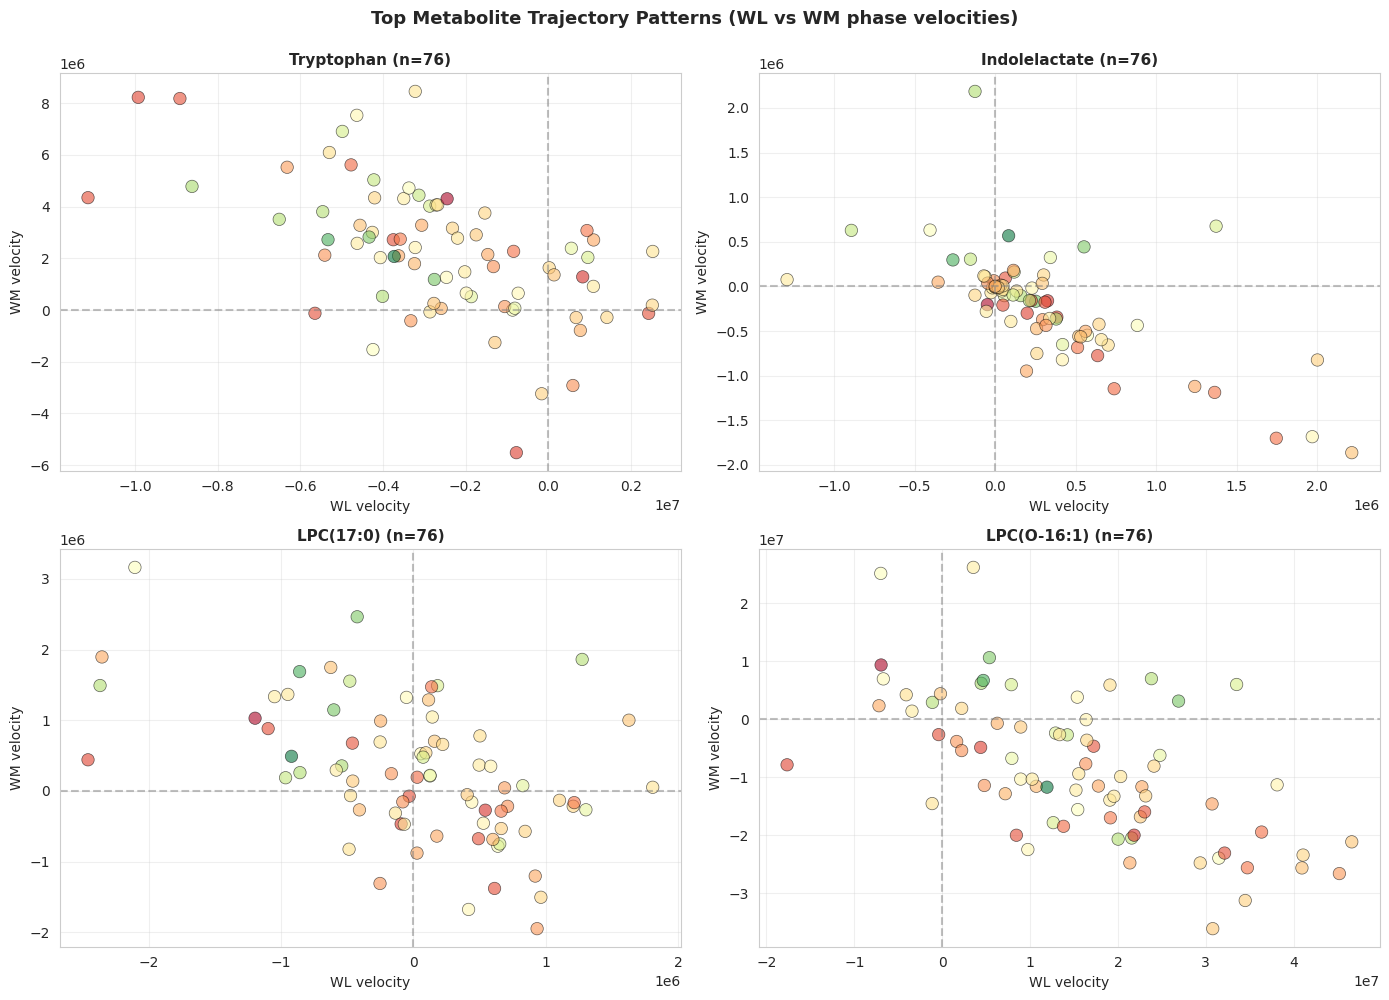

In [16]:
# Plot 3: Top metabolite trajectories
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
top_metabolites = ['Tryptophan', 'Indolelactate', 'LPC(17:0)', 'LPC(O-16:1)']
for idx, met in enumerate(top_metabolites):
    wl_col = f'WL_vel_{met}'
    wm_col = f'WM_vel_{met}'
    if wl_col in dataset_B.columns and wm_col in dataset_B.columns:
        data_met = dataset_B[[wl_col, wm_col, target_col]].dropna()
        if len(data_met) > 5:
            scatter = axes[idx].scatter(data_met[wl_col], data_met[wm_col], c=data_met[target_col],
                                        cmap='RdYlGn_r', s=80, alpha=0.6, edgecolors='black',
                                        linewidth=0.5, vmin=-12, vmax=10)
            axes[idx].set_xlabel('WL velocity', fontsize=10)
            axes[idx].set_ylabel('WM velocity', fontsize=10)
            axes[idx].set_title(f'{met} (n={len(data_met)})', fontsize=11, fontweight='bold')
            axes[idx].axhline(0, color='gray', linestyle='--', alpha=0.5)
            axes[idx].axvline(0, color='gray', linestyle='--', alpha=0.5)
            axes[idx].grid(True, alpha=0.3)

plt.suptitle('Top Metabolite Trajectory Patterns (WL vs WM phase velocities)', fontsize=13,
             fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'temporal_03_metabolite_trajectories.png', dpi=150, bbox_inches='tight')
print("✓ temporal_03_metabolite_trajectories.png")
plt.show()

✓ temporal_04_subgroup_trajectories.png


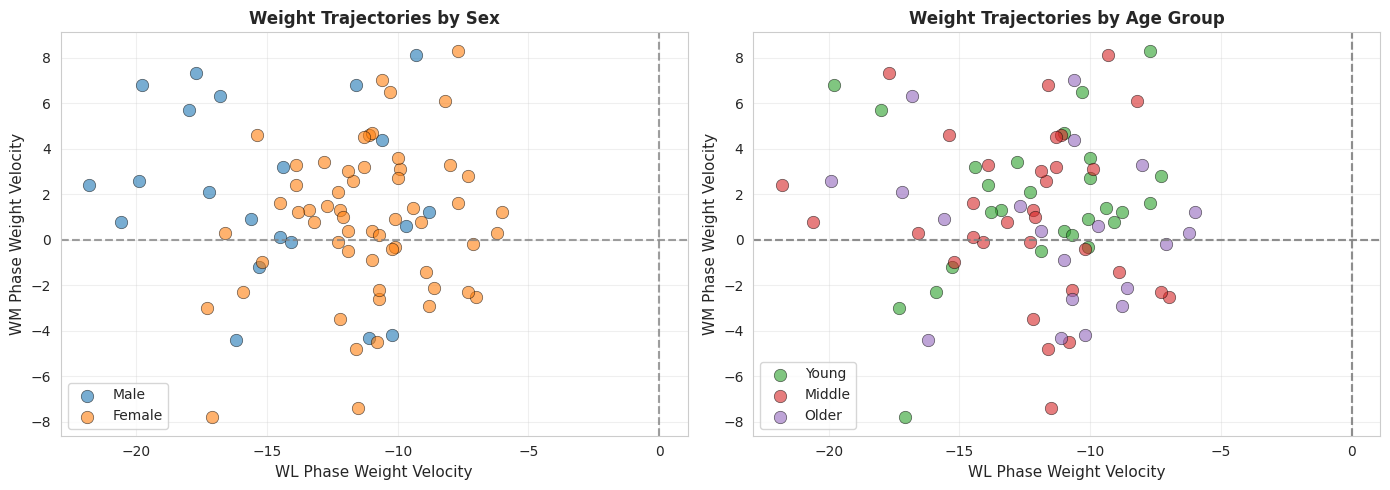

In [17]:
# Plot 4: Subgroup trajectories (sex and age)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By sex
sex_labels = {1: 'Male', 2: 'Female'}
# Optional: Define explicit colors if you don't want the matplotlib defaults
sex_colors = {1: '#1f77b4', 2: '#ff7f0e'}

for sex_val in [1, 2]:
    sex_data = merged[merged['sex'] == sex_val]
    axes[0].scatter(sex_data['WL_vel_weight'], sex_data['WM_vel_weight'],
                    color=sex_colors[sex_val], s=80, alpha=0.6,
                    label=f"{sex_labels[sex_val]}",
                    edgecolors='black', linewidth=0.5)

    axes[0].set_xlabel('WL Phase Weight Velocity', fontsize=11)
    axes[0].set_ylabel('WM Phase Weight Velocity', fontsize=11)
    axes[0].set_title('Weight Trajectories by Sex', fontsize=12, fontweight='bold')
    axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

# By age group
merged_age_plot = merged.copy()
merged_age_plot['age_group'] = pd.qcut(merged_age_plot['age'], q=3,
                                       labels=['Young', 'Middle', 'Older'], duplicates='drop')

# Optional: Define explicit colors for age groups
age_colors = {'Young': '#2ca02c', 'Middle': '#d62728', 'Older': '#9467bd'}

for age_grp in ['Young', 'Middle', 'Older']:
    age_data = merged_age_plot[merged_age_plot['age_group'] == age_grp]
    axes[1].scatter(age_data['WL_vel_weight'], age_data['WM_vel_weight'],
                    color=age_colors[age_grp], s=80, alpha=0.6,
                    label=f"{age_grp}",
                    edgecolors='black', linewidth=0.5)

    axes[1].set_xlabel('WL Phase Weight Velocity', fontsize=11)
    axes[1].set_ylabel('WM Phase Weight Velocity', fontsize=11)
    axes[1].set_title('Weight Trajectories by Age Group', fontsize=12, fontweight='bold')
    axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'temporal_04_subgroup_trajectories.png', dpi=150, bbox_inches='tight')
print("✓ temporal_04_subgroup_trajectories.png")
plt.show()

✓ exploration_05_trajectory_lines.png


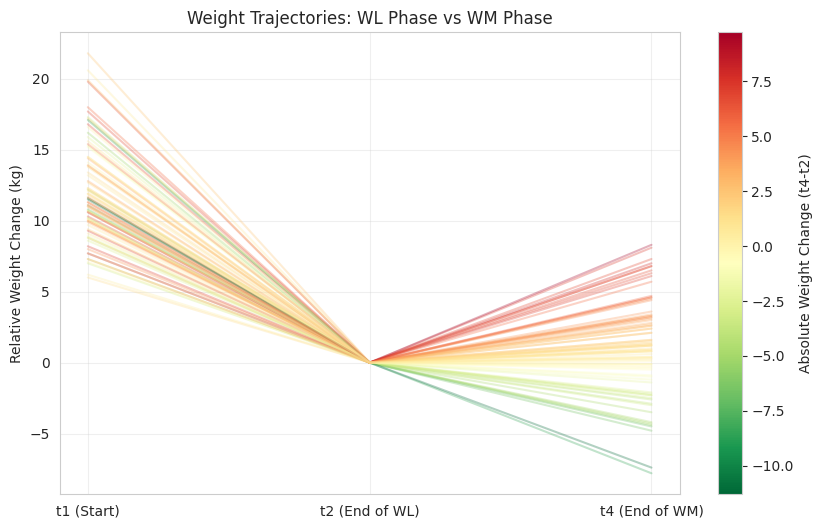

In [18]:
# 8) Success vs Regain: Weight trajectory lines
import matplotlib.cm as cm
import matplotlib.colors as colors

target = dataset_B[target_col]
norm = colors.Normalize(vmin=target.min(), vmax=target.max())
cmap = plt.get_cmap('RdYlGn_r')

plt.figure(figsize=(10, 6))

for i, row in dataset_B.iterrows():
    # Relative weights: t2 = 0
    # W_t1 = -WL_vel_weight
    # W_t4 = WM_vel_weight
    w1 = -row['WL_vel_weight']
    w2 = 0
    w4 = row['WM_vel_weight']
    
    color = cmap(norm(row[target_col]))
    plt.plot([0, 1, 2], [w1, w2, w4], color=color, alpha=0.3)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Absolute Weight Change (t4-t2)')

plt.xticks([0, 1, 2], ['t1 (Start)', 't2 (End of WL)', 't4 (End of WM)'])
plt.ylabel('Relative Weight Change (kg)')
plt.title('Weight Trajectories: WL Phase vs WM Phase')
plt.grid(True, alpha=0.3)

plt.savefig(RESULTS_DIR / 'exploration_05_trajectory_lines.png', dpi=150, bbox_inches='tight')
print("✓ exploration_05_trajectory_lines.png")
plt.show()